        Disable GPU: Force tensorflow to select CPU

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
import tensorflow as tf

2025-07-07 01:54:59.980309: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-07 01:54:59.988194: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751833499.997854  228270 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751833500.000679  228270 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751833500.007779  228270 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

        Select a GPU with a memory limit

In [1]:
# # include ../dirx 
mylibpath = [
    # '/home/kishor/src/FastDWTConvLayers',
    # '/home/kishor/src/MRSegmentation/Attentions19102023'
      # '/home/k/src/_MEDCNNsrc_part/MEDCNN_copy'
      '/home/kishoretarafdar/bin'
      # '/home/kishor/src/MEDCNN_copy'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(0,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
import tensorflow as tf

2025-06-12 12:04:13.179402: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749710053.213882 3344251 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749710053.224121 3344251 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-12 12:04:13.261232: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
gpus = tf.config.list_physical_devices('GPU')
memory_limit = 30
select_a_gpu(gpus, gpu_id=2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

3 Physical GPUs available 
Selected 1 Logical GPU with 30 GB memory limit


I0000 00:00:1749710057.020611 3344251 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 30720 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


        GPU status...

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)

Num GPUs Available:  0


2025-06-16 20:53:10.462518: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-06-16 20:53:10.462564: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: meherangarh
2025-06-16 20:53:10.462572: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: meherangarh
2025-06-16 20:53:10.462749: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: 570.148.8
2025-06-16 20:53:10.462775: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 570.148.8
2025-06-16 20:53:10.462780: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:259] kernel version seems to match DSO: 570.148.8


0

        Vineet's code

In [7]:
import numpy as np
import pywt
from scipy.signal import freqz
import matplotlib.pyplot as plt
import time


class ShearletTransform2D:
    def __init__(self, N, J, L=None, B=None, a=None, norm=False):
        def v(x):
            return np.piecewise(x, [x<=0, x>=1], [0, 1, lambda x: x**3*(10-15*x+6*x**2)])  # 3 vanishing moments
            # return np.piecewise(x, [x<=0, x>=1], [0, 1, lambda x: x**4*(35-84*x+70*x**2-20*x**3)])  # 4 vanishing moments
        def phi(x):
            x = 1/np.pi*np.abs(x)
            return np.piecewise(x, [x<=1, np.logical_and(x>1, x<2)], [1, lambda x: np.cos(0.5*np.pi*v(x-1)), 0])
        def W(x, ljbj, ljbj_1):
            return np.sqrt(np.square(phi(x/ljbj))-np.square(phi(x/ljbj_1)))
        def V(x):
            if False:
                return np.piecewise(x, [np.logical_and(x>-1, x<1)], [lambda x: np.sqrt(v(1-np.abs(x))), 0])
            else:
                x = np.pi*x
                wavelet = pywt.Wavelet('db3')
                # wavelet = pywt.Wavelet('db4')
                h0 = wavelet.dec_lo
                return np.abs(freqz(h0/np.sqrt(2), worN=np.clip(x, -np.pi, np.pi))[1])
        def centered_wrap(x, half_modulo=np.pi):
            return (x+half_modulo)%(2*half_modulo)-half_modulo
        def downsample(x, fac=2):
            return sum(np.split(sum(np.split(x, fac, -1)), fac, -2))
            # return np.fft.fft2(np.fft.ifft2(x)[..., ::fac, ::fac]).astype(x.dtype)
        def get_shearlet_system():
            shearlet_system = [[], [], []]
            temp = centered_wrap(np.linspace(0, 2*np.pi, N, endpoint=False), np.pi)
            w = np.stack(np.meshgrid(temp, temp, copy=False, indexing='ij'), axis=0)
            
            temp = np.abs(w)
            XP0 = temp[1]<=temp[0]
            XP1 = np.logical_not(XP0)

            w0 = w[0, :, :1]
            shearlet = phi((L[J-1]*B[J-1])*w0)
            shearlet = shearlet*XP0 + shearlet.transpose(1, 0)*XP1
            shearlet_system[0].append(shearlet)
            
            temp = w[0]
            ratio = np.divide(w[1], temp, out=np.full_like(temp, np.inf), where=temp!=0)

            for j in range(J):
                W0 = W(w0, (L[j]*B[j])/(L[J-1]*B[J-1]), (1 if j==0 else L[j-1]*B[j-1])/(L[J-1]*B[J-1]))
                W1 = W0.transpose(1, 0)*XP1
                W0 = W0*XP0
                temp = L[j]*ratio

                for l1 in range(-L[j], L[j]+1):
                    shearlet = V(temp-l1)
                    if abs(l1)==L[j]:
                        shearlet = shearlet*W0 + shearlet.transpose(1, 0)*W1
                        shearlet_system[2].append(shearlet)
                    else:
                        shearlet = shearlet*W0
                        shearlet_system[1].append(shearlet)
            for i in range(3):
                shearlet_system[i] = np.stack(shearlet_system[i], axis=0)
            return shearlet_system

        if a is not None:
            L = [int(np.round(a**((1-1/2)*j))) for j in range(J)]
            B = [a**(j+1)/L[j] for j in range(J)]

        self.N = N
        self.J = J
        self.L = L
        self.B = B
        self.norm = norm
        self.shearlet_system = get_shearlet_system()
        
        if self.norm:
            self.norm_factors = [np.sum(np.square(np.abs(filters)), axis=(-2, -1), keepdims=True) for filters in self._yield_filters()]
            self.norm_factors = np.concatenate(self.norm_factors, axis=-3)
            self.norm_factors = np.sqrt(N**2/self.norm_factors)
            

    def _yield_filters(self):
        yield self.shearlet_system[0]
        yield self.shearlet_system[1]
        yield self.shearlet_system[1].transpose(0, 2, 1)
        yield self.shearlet_system[2]
        
    def _filtering(self, y, filters):
        y = y*filters
        y = np.fft.ifftn(y, axes=(-2, -1))
        return y
        
    def __call__(self, x):
        y = np.fft.fftn(x, [self.N]*2)
        y = np.expand_dims(y, axis=-3)
        filtered = []
        for filters in self._yield_filters():
            temp = self._filtering(y, filters)
            filtered.append(temp)
        filtered = np.concatenate(filtered, axis=-3)
        filtered = filtered[..., :x.shape[-2], :x.shape[-1]]
        if self.norm:
            filtered *= self.norm_factors
        return filtered
        
    def forward(self, x):
        return self(x)
        
    def _synthesis(self, y, idx, filters):
        y = y[..., idx:idx+filters.shape[0], :, :]
        y = np.fft.fftn(y, [self.N]*2)
        y = y*filters
        y = np.sum(y, axis=-3)
        return y, idx+filters.shape[0]
        
    def inverse(self, y):
        if self.norm:
            y = y/self.norm_factors
        synthesized = 0
        idx = 0
        for filters in self._yield_filters():
            temp, idx = self._synthesis(y, idx, filters)
            synthesized += temp
        synthesized = np.fft.ifftn(synthesized, axes=(-2, -1))
        synthesized = synthesized[..., :y.shape[-2], :y.shape[-1]]
        return synthesized


n = 128
start_time = time.time()
ST2D = ShearletTransform2D(N=n, J=3, L=[2, 4, 8], B=[1, 1, 1], norm=True)
print(time.time()-start_time)

x = np.random.randn(n, n)
start_time = time.time()
y = ST2D(x)
print(time.time()-start_time)
print(y.shape)

start_time = time.time()
x_ = ST2D.inverse(y)
print(time.time()-start_time)
print(x_.shape)

print(np.max(np.abs(x_-x)))

0.05830836296081543
0.02899956703186035
(57, 128, 128)
0.029040098190307617
(128, 128)
2.307604144222744e-15


---

<br><br><br><br><br><br><br><br><br>
<br><br><br><br><br><br><br><br><br>
<br><br><br><br><br><br><br><br><br>



        tf version
        added support for biorthogonal wavelets
        removed numpy dependency
        removed feqz dependency

In [4]:
import tensorflow as tf
import numpy as np
import pywt
# from scipy.signal import freqz
import matplotlib.pyplot as plt
import time


class ShearletTransform2D(tf.keras.layers.Layer):
    """ Shearlet transform 2D
    
    TFDST: Fast Discrete Shearlet Transform Layers in TensorFlow.
    Copyright (C) 2025 Vineet Ghule and Kishore Kumar Tarafdar

    This program is free software: you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation, either version 3 of the License, or
    (at your option) any later version.

    This program is distributed in the hope that it will be useful,
    but WITHOUT ANY WARRANTY; without even the implied warranty of
    MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
    GNU General Public License for more details.

    You should have received a copy of the GNU General Public License
    along with this program.  If not, see <https://www.gnu.org/licenses/>.
    """
    def __init__(
        self, N, 
        J, 
        L=None, B=None, 
        a=None, 
        norm=False, 
        wave='db3',
        transform=None, ## inverse
        **kwargs):
        super().__init__(**kwargs)
        self.transform = transform ## inverse
        self.wave = wave
        self.π = tf.constant(np.pi, dtype=tf.float64)
        self.N = N
        self.J = J
        self.L = L
        self.B = B
        self.norm = norm
        self.shearlet_system = self.get_shearlet_system('wavedec')
        if 'bio' in self.wave:
            self.shearlet_system_rec = self.get_shearlet_system('waverec')
        else: self.shearlet_system_rec = None
        if a is not None:
            L = [int(tf.math.round(a**((1-1/2)*j))) for j in range(J)]
            B = [a**(j+1)/L[j] for j in range(J)]
        if self.norm:
            self.norm_factors = self.get_norm_factors()
        
    @tf.function
    def get_norm_factors(self):
        """ Normalizing with thre reconstruction Filterbank!!! recheck here!!!"""       
        FBdec, _ = self.getFB()
        # Compute the squared L2 norm over the spatial dimensions
        norm_factors = tf.reduce_sum(tf.math.square(tf.math.abs(FBdec)), axis=(-2, -1), keepdims=True)  # shape: [F, 1, 1, 1]
        norm_factors = tf.math.sqrt(self.N**2/norm_factors)
        return tf.cast(norm_factors, tf.complex128)
         
    @tf.function
    def v(self, x):
        x = tf.cast(x, tf.float64)  # Ensure consistent dtype if needed
        # Constants casted to match x's dtype
        ten = tf.constant(10.0, dtype=x.dtype)
        fifteen = tf.constant(15.0, dtype=x.dtype)
        six = tf.constant(6.0, dtype=x.dtype)
        one = tf.constant(1.0, dtype=x.dtype)
        zero = tf.constant(0.0, dtype=x.dtype)
        # Conditions
        cond0 = x <= zero
        cond1 = x >= one
        # Polynomial part for 0 < x < 1
        x_poly = x**3 * (ten - fifteen * x + six * x**2)
        return tf.where(cond0, zero, tf.where(cond1, one, x_poly))
    
    @tf.function
    def phi(self, x):
        x = tf.convert_to_tensor(x, dtype=tf.float64)
        x = tf.abs(x) / self.π#tf.constant(np.pi, dtype=tf.float64)
        # Conditions
        cond1 = x <= 1
        cond2 = tf.logical_and(x > 1, x < 2)
        # phi parts
        part1 = tf.ones_like(x)
        part2 = tf.cos(0.5 * self.π * self.v(x - 1))
        part3 = tf.zeros_like(x)

        return tf.where(cond1, part1, tf.where(cond2, part2, part3))
    
    @tf.function
    def W(self, x, ljbj, ljbj_1):
        return tf.math.sqrt(tf.math.square(self.phi(x/ljbj))-tf.math.square(self.phi(x/ljbj_1)))

    
    @tf.function
    def _V_piecewise_fn(self, x):
        # x = tf.convert_to_tensor(x, dtype=tf.float32)
        cond = tf.logical_and(x > -1, x < 1)
        val = tf.sqrt(self.v(1.0 - tf.abs(x)))
        return tf.where(cond, val, tf.zeros_like(x))
    @tf.function
    def _V_wavedec(self, x):
        wavelet = pywt.Wavelet(self.wave)
        h0 = wavelet.dec_lo
        return self.freqz_abs(x, h0)
    @tf.function
    def _V_waverec(self, x):
        wavelet = pywt.Wavelet(self.wave)
        g0 = wavelet.rec_lo
        return self.freqz_abs(x, g0)
    @tf.function
    def freqz_abs(self, x1, h0):
        # Ensure high precision: float64 and complex128
        # h0 = tf.convert_to_tensor(h0, dtype=tf.complex128)
        x1 = self.π*x1
        
        h0 = h0 / tf.sqrt(tf.constant(2.0, dtype=tf.float64))
        h0 = tf.cast(h0, tf.complex128)

        x1 = tf.cast(x1, tf.float64)
        # π = tf.constant(np.pi, dtype=tf.float64)
        x1_clipped = tf.clip_by_value(x1, -self.π, self.π)
        # x1_clipped = tf.clip_by_value(x1, -tf.constant(tf.constant(np.pi, dtype=tf.float64)), tf.constant(np.pi, dtype=tf.float64))
        freqs = tf.reshape(x1_clipped, [-1])  # [M]

        n = tf.range(tf.shape(h0)[0], dtype=tf.float64)  # [L]
        n = tf.reshape(n, [1, -1])                      # [1, L]
        freqs = tf.reshape(freqs, [-1, 1])              # [M, 1]

        exponent = tf.exp(-1j * tf.cast(freqs * n, tf.complex128))  # [M, L]
        response = tf.matmul(exponent, tf.reshape(h0, [-1, 1]))     # [M, 1]
        response_abs = tf.abs(response)                             # [M, 1]

        return tf.cast(tf.reshape(response_abs, tf.shape(x1)), dtype=tf.float64)
        
    
    @tf.function
    def centered_wrap(self, x, half_modulo=np.pi):
        return (x+half_modulo)%(2*half_modulo)-half_modulo

    # ## How to use this??
    @tf.function
    def downsample(self, x, fac=2):
        return tf.add_n(tf.split(tf.add_n(tf.split(x, fac, axis=-1)), fac, axis=-2))#.numpy()

    # @tf.function
    def get_shearlet_system(self, filtertype):

        def V(x):
            if filtertype == "piecewise":
                return self._V_piecewise_fn(x)
            elif filtertype == "wavedec":
                return self._V_wavedec(x)
            elif filtertype == "waverec":
                return self._V_waverec(x)
            else:
                raise ValueError(f"Unknown mode: {filtertype}")

        N = self.N
        J = self.J
        L = self.L
        B = self.B
        shearlet_system = [[], [], []]
        temp = self.centered_wrap((tf.range(N, dtype=tf.float64) * (2.0 * self.π / N)), self.π)
        w = tf.stack(tf.meshgrid(temp, temp, indexing='ij'), axis=0)
        
        temp = tf.math.abs(w)
        XP0 = temp[1]<=temp[0]
        XP1 = tf.logical_not(XP0)
        XP0 = tf.cast(XP0, dtype=tf.float64)
        XP1 = tf.cast(XP1, dtype=tf.float64)

        w0 = w[0, :, :1]
        shearlet = self.phi((L[J-1]*B[J-1])*w0)
        shearlet = shearlet*XP0 + tf.transpose(shearlet, perm=[1, 0])*XP1
        shearlet_system[0].append(shearlet)
        
        temp = w[0]
        # ratio = np.divide(w[1], temp, out=np.full_like(temp, np.inf), where=temp!=0)
        safe_temp = tf.where(temp != 0, temp, tf.constant(1.0, dtype=temp.dtype))
        ratio = tf.where(temp != 0, w[1] / safe_temp, tf.constant(float('inf'), dtype=temp.dtype))
        # safe_temp = tf.where(temp != 0, temp, tf.constant(np.inf, dtype=temp.dtype))
        # ratio = w[1] / safe_temp

        for j in range(J):
            W0 = self.W(w0, (L[j]*B[j])/(L[J-1]*B[J-1]), (1 if j==0 else L[j-1]*B[j-1])/(L[J-1]*B[J-1]))
            W1 = tf.transpose(W0, perm=[1, 0])*XP1
            W0 = W0*XP0
            temp = L[j]*ratio

            for l1 in range(-L[j], L[j]+1):
                shearlet = V(temp-l1)
                if abs(l1)==L[j]:
                    shearlet = shearlet*W0 + tf.transpose(shearlet, perm=[1, 0])*W1
                    shearlet_system[2].append(shearlet)
                else:
                    shearlet = shearlet*W0
                    shearlet_system[1].append(shearlet)
        for i in range(3):
            shearlet_system[i] = tf.stack(shearlet_system[i], axis=0)
        return shearlet_system

    # UPDATE
    def getFB(self):
        if 'bio' in self.wave:
            return self._analysis_bank_tensor(), self._synthesis_bank_tensor_biortho()
        else:
            return self._analysis_bank_tensor(), None
    def _analysis_bank_tensor(self):
        FB = [
            self.shearlet_system[0],
            self.shearlet_system[1],
            tf.transpose(self.shearlet_system[1], perm=[0, 2, 1]),
            self.shearlet_system[2],
           ]
        return tf.cast(tf.concat(FB, axis=0), tf.complex128)
    def _synthesis_bank_tensor_biortho(self):
        FB = [
            self.shearlet_system_rec[0],
            self.shearlet_system_rec[1],
            tf.transpose(self.shearlet_system_rec[1], perm=[0, 2, 1]),
            self.shearlet_system_rec[2],
        ]
        return tf.cast(tf.concat(FB, axis=0), tf.complex128)

    def forward(self, x):
        x = tf.cast(x, dtype=tf.complex128)
        xfft = tf.signal.fft2d(x)
        # FB = self._analysis_bank_tensor()
        FB, _ = self.getFB()
        filtered = tf.einsum('ij,fij->fij', xfft, FB)        
        filtered = tf.signal.ifft2d(filtered)
        # filtered = filtered[..., :x.shape[-3], :x.shape[-2], :x.shape[-1]]
        if self.norm:
            filtered *= self.norm_factors
        return filtered

    def call(self, x):
        if self.transform==None:
            return self.forward(x)
        elif self.transform=='inverse':
            return self.inverse(x)
        else:
            raise ValueError(f"Unknown key {transform}!! keys 'DST' or 'IDST' only allowed")

    def inverse(self, y):
        y = tf.cast(y, tf.complex128)
        if self.norm:
            y = y/self.norm_factors
        yfft = tf.signal.fft2d(y)             
        if 'bio' in self.wave:
            _, FB = self.getFB()
        else:
            FB, _ = self.getFB()        
        synthesized = tf.einsum('fij,fij->ij', yfft, FB)
        synthesized = tf.signal.ifft2d(synthesized)#, axes=(-3, -2, -1))
        return tf.math.real(synthesized)
        # return synthesized

    def get_config(self): 
        return {
            "N": self.N,
            "J": self.J,
            "L": self.L,
            "B": self.B,
            "wave": self.wave,
            "norm": self.norm,
            "transform": self.transform,
            "π": self.π,
            # "shearlet_system": self.shearlet_system,
            # "shearlet_system_rec": self.shearlet_system_rec
            # Optional: include any other parameters used in `get_shearlet_system`
            # and `get_norm_factors`, if needed for a full reconstruction
            }

if __name__=='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
    n = 128
    start_time = time.time()
    # ST2D = ShearletTransform2D(N=n, J=3, L=[2, 4, 8], B=[1, 1, 1], norm=True)
    ST2D = ShearletTransform2D(N=n, J=3, L=[2, 4, 8], B=[1, 1, 1], norm=True, wave='db25')
    ST2D = ShearletTransform2D(N=n, J=3, L=[2, 4, 8], B=[1, 1, 1], norm=True, wave='rbio1.5')
    print('elapsed time', time.time()-start_time)

    x = np.random.randn(n, n)
    start_time = time.time()
    y = ST2D.forward(x)
    print('elapsed time DST', time.time()-start_time)
    print(y.shape)

    start_time = time.time()
    x_ = ST2D.inverse(y)
    print('elapsed time IDST',time.time()-start_time)
    print(x_.shape)

    print('max. reconstruction error ', np.max(np.abs(x_-x)))

elapsed time 0.3238520622253418
elapsed time DST 0.0012104511260986328
(57, 128, 128)
elapsed time IDST 0.000576019287109375
(128, 128)
max. reconstruction error  2.6645352591003757e-15


# Shearlet Transform 2D layer

        Batched multichannel 
        Inherits ShearletTransform2D class

In [ ]:
import tensorflow as tf

class DST2D(ShearletTransform2D):
    """Fast DST 2D and IDST 2D layer
    
    TFDST: Fast Discrete Shearlet Transform Layers in TensorFlow.
    Copyright (C) 2025 Vineet Ghule and Kishore Kumar Tarafdar

    This program is free software: you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation, either version 3 of the License, or
    (at your option) any later version.

    This program is distributed in the hope that it will be useful,
    but WITHOUT ANY WARRANTY; without even the implied warranty of
    MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
    GNU General Public License for more details.

    You should have received a copy of the GNU General Public License
    along with this program.  If not, see <https://www.gnu.org/licenses/>.
    """
    def __init__(self, transform=None, **kwargs):#, l1=0.0, l2=0.0):
        super(DST2D, self).__init__(**kwargs)
        self.transform = transform
        if self.transform == 'inverse':
            self.name = 'IDST2D'
    
    ## UPDATE applied for batched multichannel inputs
    def forward(self, x):
        x = tf.cast(x, dtype=tf.complex128)
        # FB = self._yield_filter_bank_tensor()
        FB, _ = self.getFB()
        x = tf.transpose(x, perm=[0,3,1,2])
        xfft = tf.signal.fft2d(x)
        filtered = tf.einsum('bcij,fij->bcfij', xfft, FB)
        filtered = tf.signal.ifft2d(filtered)
        if self.norm:
            # self.norm_factors = tf.cast(self.norm_factors, dtype=tf.complex128)
            filtered *= self.norm_factors
            # filtered = tf.einsum('bcfijk,fijk->bcfijk', filtered, self.norm_factors)
        y = tf.transpose(filtered, perm=[0, 3,4, 1,2])
        ## reshape last two axis and output
        shape_tmp = tf.shape(y)
        y = tf.reshape(y, (shape_tmp[0], shape_tmp[1], shape_tmp[2], shape_tmp[3]*shape_tmp[4]))
        return y
    
    def call(self, x):
        if self.transform==None:
            return self.forward(x)
        elif self.transform=='inverse':
            return self.inverse(x)
        else:
            raise ValueError(f"Unknown key {transform}!! keys 'None' (default) or 'inverse' only allowed")

    def inverse(self, y):
        y = tf.cast(y, tf.complex128)
        ## reshape to (batch, n1,n2, channels, shearlets)
        input_shape = tf.shape(y)
        num_shearlet_filters = self.norm_factors.shape[0]
        channels = input_shape[-1] // num_shearlet_filters
        y = tf.reshape(y, (input_shape[0],input_shape[1],input_shape[2], channels, num_shearlet_filters))
        ## transpose to (batch, channels, shearlets, n1,n2,n3) 
        ## since fft3d works on last three axis
        y = tf.transpose(y, perm=[0, 3,4, 1,2])
        # self.norm_factors = tf.cast(self.norm_factors, tf.complex128)
        if self.norm:
            y = y/self.norm_factors
            # y = tf.einsum('bcfijk,fijk->bcfijk', y, 1/self.norm_factors)      
        yfft = tf.signal.fft2d(y)
        if 'bio' in self.wave:
            _, FB = self.getFB()
        else:
            FB, _ = self.getFB()  
        synthesized = tf.einsum('bcfij,fij->bcij', yfft, FB)
        synthesized = tf.cast(synthesized, tf.complex128)
        synthesized = tf.signal.ifft2d(synthesized)#, axes=(-3, -2, -1))
        synthesized = tf.transpose(synthesized, perm=[0,2,3,1])
        return tf.math.real(synthesized)


if __name__=='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"   
    # start_time = time.time()
    # ST3D = ShearletTransform3D(N=128, J=2, L=[1, 2], B=[4, 8], norm=True)
    # ST3D = DST3D(N=32, J=2, L=[1, 2], B=[4, 8], norm=True, wave='db6')
    # ST3D = DST3D(N=32, J=2, L=[1, 2], B=[4, 8], norm=True, wave='db10')
    # ST3D = DST3D(N=128, J=2, L=[1, 2], B=[4, 8], norm=True, wave='bior1.5')

    # ST3D = ShearletTransform3D(N=32, J=3, L=[1, 4, 8], B=[6, 8, 10], norm=True, wave='db20')
    # print(time.time()-start_time)
    
    ## Example 1: model summary
    import numpy as np
    n = 64
    axis1 = np.arange(0,n)
    x = np.einsum('i,j->ij', axis1, axis1)
    # x = np.einsum('i,j,k->ijk', axis1, axis1, axis1)
    xx = tf.expand_dims(tf.expand_dims(x, axis=-1), axis=0)
    xx = tf.concat([xx,xx, xx], axis=-1)
    xx.shape
    # viz(x)
    # dst3D = DST3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='db10')
    dst2D = DST2D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='bior1.5')
    # dst3D = DST3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='rbio1.5')
    dst2D.forward(xx).shape
    xxrec = dst2D.inverse(dst2D(xx))
    xxrec.dtype, xxrec.shape
    print(f"\nReconstruction error: {tf.reduce_sum(tf.abs(xxrec - tf.cast(xx,dtype=tf.float64)))}\n")

    ## Example 2: Sample functional model
    N, channels = 16, 2
    input_shape = (N, N, channels)  # Replace N with the actual size of x    #3D
    inputs = tf.keras.Input(shape=input_shape)

    H  = DST2D(N=N, J=2, L=[1, 2], B=[4, 8], norm=True, wave='bior1.5')
    Hr = DST2D(N=N, J=2, L=[1, 2], B=[4, 8], norm=True, wave='bior1.5', transform='inverse')
    q = H(inputs)
    outputs = Hr(q)
    # outputs = q
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()

    ## 3D Random data
    inputs_data = tf.random.normal((1, N, N, channels))
    targets = tf.random.normal((1, N, N, channels))
    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(inputs_data, targets, epochs=5, verbose=1)


Reconstruction error: 2.5564997782824193e-09



Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 16, 16, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dst2d_16 (DST2D)                │ (None, 16, 16, 26)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ IDST2D (DST2D)                  │ (None, 16, 16, 2)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 2.2222
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 2.2222
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.2222
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.2222
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.2222


In [4]:
# c = 2
# input_shape = (n,n,c)
# inputs = tf.keras.Input(input_shape)

# H  = DST2D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='bior1.5')
# Hr = DST2D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='bior1.5', transform='inverse')
# q = H(inputs)
# outputs = Hr(q)
# # outputs = q
# model = tf.keras.Model(inputs=inputs, outputs=outputs)
# model.summary()

In [5]:
# if __name__=='__main__':
#     start_time = time.time()
#     # ST3D = ShearletTransform3D(N=128, J=2, L=[1, 2], B=[4, 8], norm=True)
#     # ST3D = ShearletTransform3D(N=32, J=2, L=[1, 2], B=[4, 8], norm=True, wave='db15')
#     # ST3D = ShearletTransform3D(N=32, J=2, L=[1, 2], B=[4, 8], norm=True, wave='bior1.5')
#     ST3D = ShearletTransform3D(N=128, J=2, L=[1, 2], B=[4, 8], norm=True, wave='db15')

#     # ST3D = ShearletTransform3D(N=32, J=3, L=[1, 4, 8], B=[6, 8, 10], norm=True, wave='db20')
#     print(time.time()-start_time)

#     ## Example: shearlet filters
#     ## view filters
#     print(ST3D)
#     ## get the shearlet system
#     sys3d = ST3D.shearlet_system
#     len(sys3d), type(sys3d)
#     np.squeeze(sys3d[0]).shape
#     # print filter shapes
#     print('\nFilter shapes: ',[_.shape for _ in sys3d])
#     print('Filter dtypes: ',[_.dtype for _ in sys3d])


#     ## Example: perfect reconstruction 
#     ## check perfect reconstruction
#     n = 128
#     axis1 = np.arange(0,n)
#     x = np.einsum('i,j->ij', axis1, axis1)
#     x = np.einsum('i,j,k->ijk', axis1, axis1, axis1)
#     # viz(x)
#     ST3D = ShearletTransform3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='rbio1.5')
#     print(f"\nReconstruction error: {tf.reduce_sum(tf.abs(ST3D.inverse(ST3D.forward(x)) - x))}\n")
#     # viz(ST3D.inverse(ST3D(x)))

In [133]:
# y = ST2D.ydum
# synthesized = ST2D.syndum
# synthesized

In [132]:
# synthesized = synthesized[..., :y.shape[-2], :y.shape[-1]]
# synthesized

In [4]:
[_.shape for _ in ST2D.shearlet_system]

[TensorShape([1, 128, 128]),
 TensorShape([25, 128, 128]),
 TensorShape([6, 128, 128])]

        view Filter Bank

(57, 128, 128)


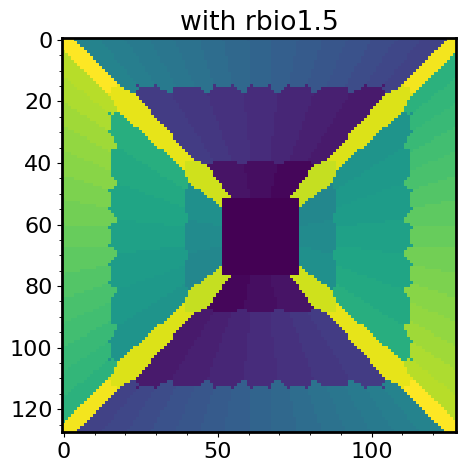

In [5]:
# Set rcParams for customizations
plt.rcParams['figure.figsize'] = (5, 5)  # Default figure size
plt.rcParams['figure.dpi'] = 100         # Adjust figure DPI for better resolution
plt.rcParams['figure.autolayout'] = True # Automatically adjust subplot parameters to fit the figure
plt.rcParams['figure.titlesize'] = 16     # Figure title font size
plt.rcParams['font.size'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['xtick.minor.visible'] = True  # Show minor ticks on x-axis
plt.rcParams['ytick.minor.visible'] = True  # Show minor ticks on y-axis
plt.rcParams['axes.grid'] = False  
plt.rcParams['axes.grid.which'] = 'both' # Show both major and minor grids
plt.rcParams['axes.linewidth'] = 2.0  
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['grid.linestyle'] = ':'     # Set grid line style to dotted
plt.rcParams['grid.linewidth'] = 1     # Set grid line width
plt.rcParams['legend.fontsize'] = 16      # Legend font size

sys2d = tf.concat([
    ST2D.shearlet_system[0],
    ST2D.shearlet_system[1],
    tf.transpose(ST2D.shearlet_system[1], perm=[0, 2, 1]),
    ST2D.shearlet_system[2]], axis=0)
print(sys2d.shape)
blob = np.argmax(sys2d, axis=0)
blob.shape
plt.imshow(tf.signal.ifftshift(blob)), plt.title(f'with {ST2D.wave}')
del blob

        view individual set of filters in the Filter Bank

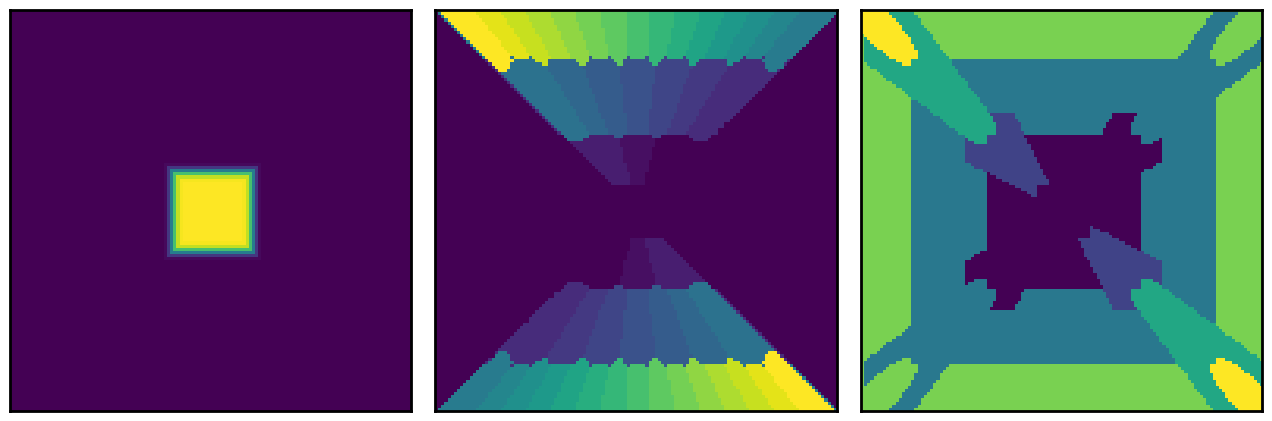

In [42]:
plt.figure(figsize=(13,6))
plt.subplot(131), plt.imshow(tf.signal.ifftshift(np.squeeze(ST2D.shearlet_system[0])))
plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(tf.signal.ifftshift(np.argmax(ST2D.shearlet_system[1], axis=0)))
plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(tf.signal.ifftshift(np.argmax(ST2D.shearlet_system[2], axis=0)))
plt.xticks([]), plt.yticks([])
plt.tight_layout()

        view a random HF filter

(([], []), ([], []))

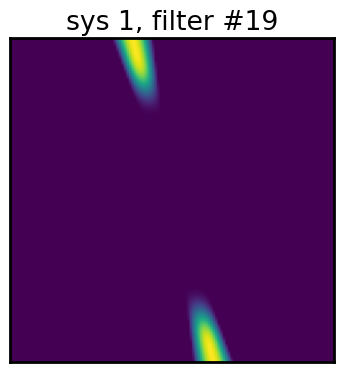

In [41]:
sys = 1
plt.figure(figsize=(4,4))
f = np.random.randint(ST2D.shearlet_system[sys].shape[0])
plt.imshow(tf.signal.ifftshift(ST2D.shearlet_system[sys][f,...])), plt.title(f'sys {sys}, filter #{f}')
plt.xticks([]), plt.yticks([])


        view all individual HF filters
        HF sys 1

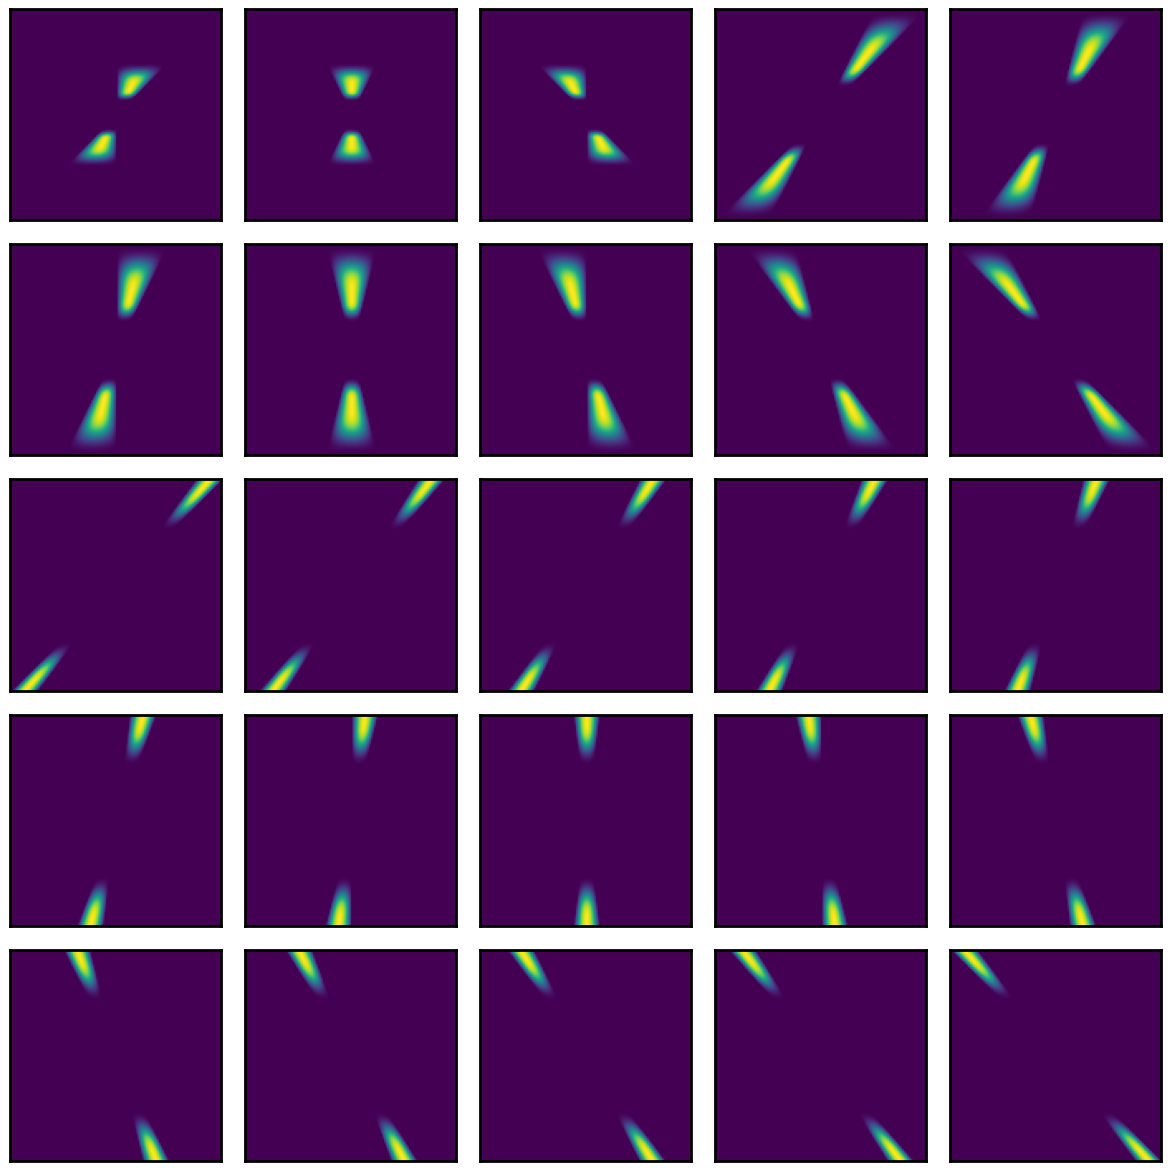

In [40]:
sys = 1
# def view_a_filt(sys):
#     f = np.random.randint(ST2D.shearlet_system[sys].shape[0])
#     plt.imshow(tf.signal.ifftshift(ST2D.shearlet_system[sys][f,...])), plt.title(f'#{f}')
plt.figure(figsize=(12,12))
filts = 25
for f in range(0,filts):
    # print(f)
    plt.subplot(5, 5, f+1)
    plt.imshow(tf.signal.ifftshift(ST2D.shearlet_system[sys][f,...]))#, plt.title(f'#{f}')
    # view_a_filt(sys)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

        HF system 2

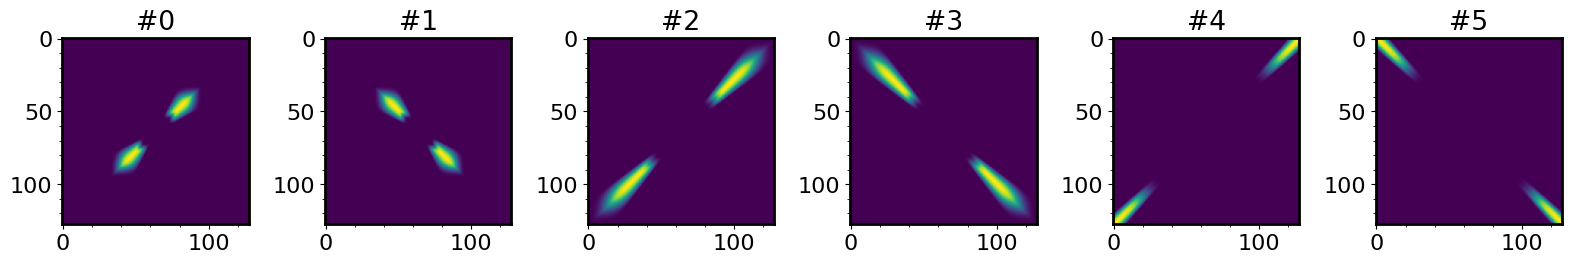

In [15]:
sys = 2
# def view_a_filt(sys):
#     f = np.random.randint(ST2D.shearlet_system[sys].shape[0])
#     plt.imshow(tf.signal.ifftshift(ST2D.shearlet_system[sys][f,...])), plt.title(f'#{f}')
plt.figure(figsize=(16,8))
for f in range(0,6):
    # print(f)
    plt.subplot(1, 6, f+1)
    plt.imshow(tf.signal.ifftshift(ST2D.shearlet_system[sys][f,...])), plt.title(f'#{f}')
    # view_a_filt(sys)
plt.tight_layout()